In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import MinMaxScaler

In [2]:
data=pd.read_csv("../datasets/PJME_hourly.csv")

In [3]:
data['Datetime']=pd.to_datetime(data['Datetime'])

In [4]:
#sort by time
data=data.sort_values('Datetime')
#set datetime as index
data.set_index('Datetime',inplace=True)
#verify
data.head()

,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


In [13]:
# Count duplicate datetime index values
print(data.index.duplicated().sum())

4


In [14]:
duplicates=data[data.index.duplicated(keep=False)]
duplicates.head(20)

,PJME_MW
Datetime,
2014-11-02 02:00:00,23755.0
2014-11-02 02:00:00,22935.0
2015-11-01 02:00:00,21567.0
2015-11-01 02:00:00,21171.0
2016-11-06 02:00:00,20795.0
2016-11-06 02:00:00,21692.0
2017-11-05 02:00:00,21236.0
2017-11-05 02:00:00,20666.0


In [15]:
# Combine duplicate timestamps by taking the average
data = data.groupby(data.index).mean()
# Verify duplicates are removed
print(data.index.duplicated().sum())

0


# Handle Missing timestamps

In [16]:
# Create complete hourly timeline
full_range = pd.date_range(start=data.index.min(),end=data.index.max(),freq="1h")
# Reindex to complete timeline
data = data.reindex(full_range)
# Rename index
data.index.name = "Datetime"
# Count inserted missing timestamps
missing_timestamps = data.isnull().all(axis=1).sum()
print("Missing timestamps inserted:", missing_timestamps)

Missing timestamps inserted: 30


# Handle Missing Values

In [18]:
# Missing values before treatment
print(data.isnull().sum())
# Time-based interpolation
data['PJME_MW']=data['PJME_MW'].interpolate(method='time')
# Forward fill remaining values
data['PJME_MW']=data['PJME_MW'].ffill()
# Backward fill remaining values
data['PJME_MW']=data['PJME_MW'].bfill()
# Verify
print(data.isnull().sum())

PJME_MW    30
dtype: int64
PJME_MW    0
dtype: int64


# Detect outliers using IQR

In [19]:
Q1=data['PJME_MW'].quantile(0.25)
Q3=data['PJME_MW'].quantile(0.75)
IQR = Q3 - Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outliers=data[(data['PJME_MW'] < lower_bound)|(data['PJME_MW'] > upper_bound)]
print('Number of outliers:', len(outliers))

Number of outliers: 3460


# Treat outliers by capping

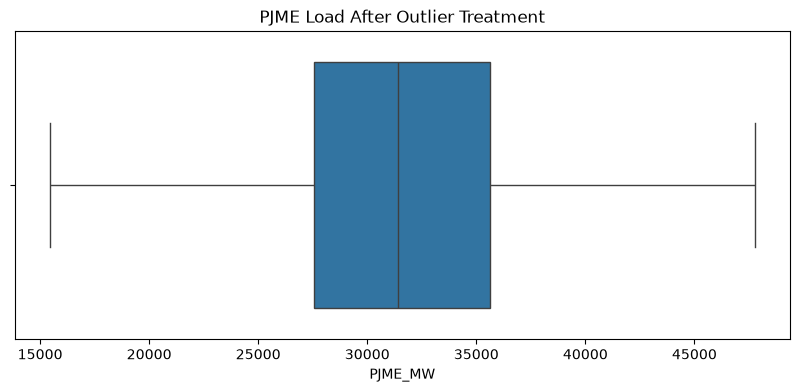

In [20]:
data['PJME_MW'] = data['PJME_MW'].clip(lower=lower_bound,upper=upper_bound)
plt.figure(figsize=(10,4))
sns.boxplot(x=data['PJME_MW'])
plt.title('PJME Load After Outlier Treatment')
plt.show()

# Resample data 

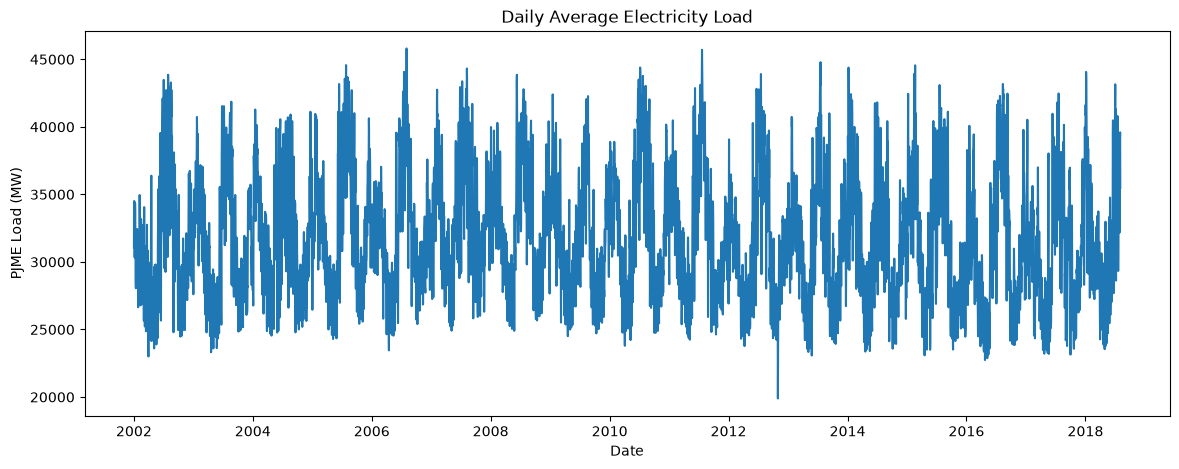

In [21]:
daily_load=data['PJME_MW'].resample('D').mean()
plt.figure(figsize=(14,5))
plt.plot(daily_load)
plt.title('Daily Average Electricity Load')
plt.xlabel('Date')
plt.ylabel('PJME Load (MW)')
plt.show()

# Normalize the target variable

In [22]:
scaler=MinMaxScaler()
data['PJME_MW_Scaled']=scaler.fit_transform(data[['PJME_MW']])
data[['PJME_MW', 'PJME_MW_Scaled']].head()

,PJME_MW,PJME_MW_Scaled
Datetime,,
2002-01-01 01:00:00,30393.0,0.462358
2002-01-01 02:00:00,29265.0,0.427439
2002-01-01 03:00:00,28357.0,0.399331
2002-01-01 04:00:00,27899.0,0.385154
2002-01-01 05:00:00,28057.0,0.390045


In [23]:
data.describe()

,PJME_MW,PJME_MW_Scaled
count,145392.000000,145392.000000
mean,31997.681774,0.512032
std,6226.858310,0.192758
min,15457.000000,0.000000
25%,27571.000000,0.375000
50%,31420.000000,0.494149
75%,35647.000000,0.625000
max,47761.000000,1.000000


# Create time-based features

In [24]:
data['Hour'] = data.index.hour
data['Day'] = data.index.day
data['Week'] = data.index.isocalendar().week.astype(int)
data['Month'] = data.index.month
data['DayOfWeek'] = data.index.dayofweek
data['Weekend'] = (data.index.dayofweek >= 5).astype(int)
data.head()

,PJME_MW,PJME_MW_Scaled,Hour,Day,Week,Month,DayOfWeek,Weekend
Datetime,,,,,,,,
2002-01-01 01:00:00,30393.0,0.462358,1,1,1,1,1,0
2002-01-01 02:00:00,29265.0,0.427439,2,1,1,1,1,0
2002-01-01 03:00:00,28357.0,0.399331,3,1,1,1,1,0
2002-01-01 04:00:00,27899.0,0.385154,4,1,1,1,1,0
2002-01-01 05:00:00,28057.0,0.390045,5,1,1,1,1,0


# Create Lag features

In [25]:
data['Lag_1'] = data['PJME_MW'].shift(1)
data['Lag_24'] = data['PJME_MW'].shift(24)
data['Lag_48'] = data['PJME_MW'].shift(48)
data['Lag_168'] = data['PJME_MW'].shift(168)
data[['PJME_MW', 'Lag_1', 'Lag_24', 'Lag_168']].head(30)

,PJME_MW,Lag_1,Lag_24,Lag_168
Datetime,,,,
2002-01-01 01:00:00,30393.0,NaN,NaN,NaN
2002-01-01 02:00:00,29265.0,30393.0,NaN,NaN
2002-01-01 03:00:00,28357.0,29265.0,NaN,NaN
2002-01-01 04:00:00,27899.0,28357.0,NaN,NaN
2002-01-01 05:00:00,28057.0,27899.0,NaN,NaN
2002-01-01 06:00:00,28654.0,28057.0,NaN,NaN
2002-01-01 07:00:00,29308.0,28654.0,NaN,NaN
2002-01-01 08:00:00,29595.0,29308.0,NaN,NaN
2002-01-01 09:00:00,29943.0,29595.0,NaN,NaN


# Create rolling features

In [27]:
data['RollingMean_24']=(data['PJME_MW'].rolling(window=24).mean())
data['RollingStd_24']=(data['PJME_MW'].rolling(window=24).std())
data['RollingMean_168']=(data['PJME_MW'].rolling(window=168).mean())
data[['PJME_MW','RollingMean_24','RollingStd_24','RollingMean_168']].head(200)

,PJME_MW,RollingMean_24,RollingStd_24,RollingMean_168
Datetime,,,,
2002-01-01 01:00:00,30393.0,NaN,NaN,NaN
2002-01-01 02:00:00,29265.0,NaN,NaN,NaN
2002-01-01 03:00:00,28357.0,NaN,NaN,NaN
2002-01-01 04:00:00,27899.0,NaN,NaN,NaN
2002-01-01 05:00:00,28057.0,NaN,NaN,NaN
...,...,...,...,...
2002-01-09 04:00:00,27759.0,34260.750000,3734.743158,33010.452381
2002-01-09 05:00:00,28308.0,34221.041667,3794.795858,33009.875000
2002-01-09 06:00:00,30169.0,34171.916667,3840.956028,33006.428571


# Remove rows created by lag and rolling operations

In [28]:
data=data.dropna()
print(data.shape)

(145224, 15)


In [29]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 145224 entries, 2002-01-08 01:00:00 to 2018-08-03 00:00:00
Freq: h
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   PJME_MW          145224 non-null  float64
 1   PJME_MW_Scaled   145224 non-null  float64
 2   Hour             145224 non-null  int32  
 3   Day              145224 non-null  int32  
 4   Week             145224 non-null  int64  
 5   Month            145224 non-null  int32  
 6   DayOfWeek        145224 non-null  int32  
 7   Weekend          145224 non-null  int64  
 8   Lag_1            145224 non-null  float64
 9   Lag_24           145224 non-null  float64
 10  Lag_48           145224 non-null  float64
 11  Lag_168          145224 non-null  float64
 12  RollingMean_24   145224 non-null  float64
 13  RollingStd_24    145224 non-null  float64
 14  RollingMean_168  145224 non-null  float64
dtypes: float64(9), int32(4), int64(2)
memory usage: 15.5 M

In [30]:
data.head()

,PJME_MW,PJME_MW_Scaled,Hour,Day,Week,Month,DayOfWeek,Weekend,Lag_1,Lag_24,Lag_48,Lag_168,RollingMean_24,RollingStd_24,RollingMean_168
Datetime,,,,,,,,,,,,,,,
2002-01-08 01:00:00,29445.0,0.433011,1,8,2,1,1,0,31187.0,26862.0,27100.0,30393.0,33560.208333,4425.965952,32513.869048
2002-01-08 02:00:00,28670.0,0.409021,2,8,2,1,1,0,29445.0,25976.0,26097.0,29265.0,33672.458333,4256.159403,32510.327381
2002-01-08 03:00:00,28375.0,0.399889,3,8,2,1,1,0,28670.0,25641.0,25793.0,28357.0,33786.375000,4064.104959,32510.434524
2002-01-08 04:00:00,28542.0,0.405058,4,8,2,1,1,0,28375.0,25666.0,25657.0,27899.0,33906.208333,3851.076461,32514.261905
2002-01-08 05:00:00,29261.0,0.427316,5,8,2,1,1,0,28542.0,26328.0,25778.0,28057.0,34028.416667,3640.941409,32521.428571


In [32]:
data.tail()

,PJME_MW,PJME_MW_Scaled,Hour,Day,Week,Month,DayOfWeek,Weekend,Lag_1,Lag_24,Lag_48,Lag_168,RollingMean_24,RollingStd_24,RollingMean_168
Datetime,,,,,,,,,,,,,,,
2018-08-02 20:00:00,44057.0,0.885339,20,2,31,8,3,0,45641.0,46912.0,40289.0,46337.0,39902.916667,6368.579836,35879.916667
2018-08-02 21:00:00,43256.0,0.860544,21,2,31,8,3,0,44057.0,45985.0,39938.0,44542.0,39789.208333,6278.997878,35872.261905
2018-08-02 22:00:00,41552.0,0.807795,22,2,31,8,3,0,43256.0,44094.0,38610.0,42638.0,39683.291667,6224.428358,35865.797619
2018-08-02 23:00:00,38500.0,0.713317,23,2,31,8,3,0,41552.0,40666.0,35950.0,39276.0,39593.041667,6225.262959,35861.178571
2018-08-03 00:00:00,35486.0,0.620016,0,3,31,8,4,0,38500.0,37158.0,33072.0,35742.0,39523.375000,6262.939842,35859.654762


In [33]:
data.columns


Index(['PJME_MW', 'PJME_MW_Scaled', 'Hour', 'Day', 'Week', 'Month',
       'DayOfWeek', 'Weekend', 'Lag_1', 'Lag_24', 'Lag_48', 'Lag_168',
       'RollingMean_24', 'RollingStd_24', 'RollingMean_168'],
      dtype='str')

In [34]:
data.to_csv('../datasets/PJME_preprocessd.csv')